# FedSafe-Crash — Day 1

The aim of this notebook is to inspect the STATS19 collision data and
examine whether police forces can be used as federated clients.

## 1. Project folders

In [3]:
from pathlib import Path

project_dir = Path("/content/fedsafe-crash")
raw_data_dir = project_dir / "data" / "raw"
results_dir = project_dir / "results"

raw_data_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_dir)

Project directory: /content/fedsafe-crash


## 2. Download the collision data

In [4]:
from urllib.request import urlretrieve

data_url = (
    "https://data.dft.gov.uk/road-accidents-safety-data/"
    "dft-road-casualty-statistics-collision-last-5-years.csv"
)

data_path = (
    raw_data_dir
    / "dft-road-casualty-statistics-collision-last-5-years.csv"
)

if not data_path.exists():
    urlretrieve(data_url, data_path)

print("Data path:", data_path)
print("File size:", round(data_path.stat().st_size / 1024**2, 2), "MB")

Data path: /content/fedsafe-crash/data/raw/dft-road-casualty-statistics-collision-last-5-years.csv
File size: 93.14 MB


## 3. Load the data

In [5]:
import pandas as pd

df = pd.read_csv(data_path, low_memory=False)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Rows: 513801
Columns: 44


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M102225,2025,17M102225,449804.0,519612.0,-1.23119,54.56929,17,3,1,...,-1,0,1,1,2,E01012092,3,1,0.0,1.0
1,202417S111924,2024,17S111924,444670.0,520502.0,-1.31046,54.57776,17,2,1,...,-1,0,1,1,2,E01012194,7,1,1.0,0.0
2,2025111687011,2025,111687011,427772.0,515144.0,-1.57237,54.53082,11,3,2,...,-1,0,1,3,2,E01035185,3,1,0.0,1.0
3,2025070326701,2025,070326701,351585.0,382993.0,-2.72862,53.34161,7,1,1,...,-1,0,1,1,2,E01012430,1,1,0.0,0.0
4,2025070353559,2025,070353559,351101.0,382954.0,-2.73589,53.34121,7,3,2,...,-1,0,1,2,2,E01012431,3,1,0.0,1.0


## 4. Check the main columns

In [6]:
columns_to_check = [
    "collision_index",
    "accident_year",
    "date",
    "collision_severity",
    "police_force",
    "local_authority_district",
    "urban_or_rural_area",
]

available_columns = [
    column for column in columns_to_check
    if column in df.columns
]

print("Available columns:")
print(available_columns)

Available columns:
['collision_index', 'date', 'collision_severity', 'police_force', 'local_authority_district', 'urban_or_rural_area']


## 5. Create the binary target

STATS19 severity codes:

- 1: Fatal
- 2: Serious
- 3: Slight

The binary target is defined as:

- 0: Slight
- 1: Serious or fatal

In [7]:
severity_map = {
    1: 1,
    2: 1,
    3: 0,
}

df["target_binary"] = (
    pd.to_numeric(
        df["collision_severity"],
        errors="coerce",
    )
    .map(severity_map)
    .astype("Int64")
)

class_distribution = (
    df["target_binary"]
    .value_counts(dropna=False)
    .rename_axis("target")
    .reset_index(name="count")
)

class_distribution["label"] = (
    class_distribution["target"]
    .map({
        0: "slight",
        1: "serious_or_fatal",
    })
    .fillna("missing")
)

class_distribution["proportion"] = (
    class_distribution["count"] / len(df)
)

display(class_distribution)

,target,count,label,proportion
0,0,389435,slight,0.757949
1,1,124366,serious_or_fatal,0.242051


## 6. Plot the class distribution

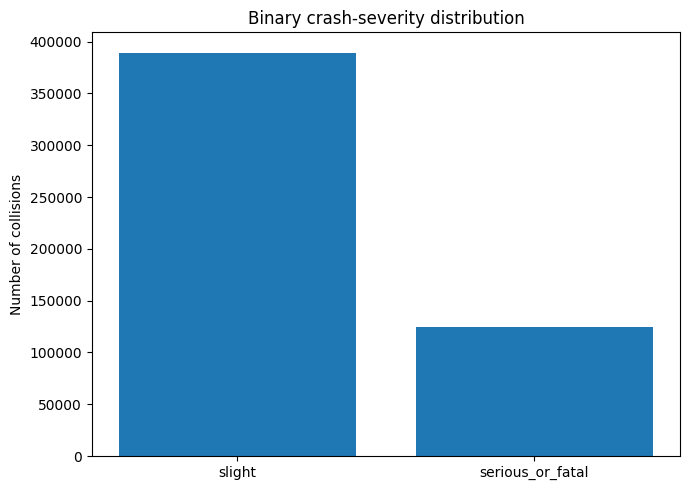

In [8]:
import matplotlib.pyplot as plt

plot_data = class_distribution[
    class_distribution["label"] != "missing"
]

plt.figure(figsize=(7, 5))
plt.bar(
    plot_data["label"],
    plot_data["count"],
)
plt.xlabel("")
plt.ylabel("Number of collisions")
plt.title("Binary crash-severity distribution")
plt.tight_layout()
plt.show()

## 7. Check the time period

In [9]:
if "accident_year" in df.columns:
    years = pd.to_numeric(
        df["accident_year"],
        errors="coerce",
    )
else:
    dates = pd.to_datetime(
        df["date"],
        dayfirst=True,
        errors="coerce",
    )
    years = dates.dt.year

print("First year:", int(years.min()))
print("Last year:", int(years.max()))

display(
    years
    .value_counts()
    .sort_index()
    .rename_axis("year")
    .reset_index(name="collisions")
)

First year: 2021
Last year: 2025


,year,collisions
0,2021,101087
1,2022,106004
2,2023,104258
3,2024,100927
4,2025,101525


## 8. Treat police forces as clients

Each police force is treated as one federated client.

In [10]:
client_summary = (
    df.dropna(
        subset=[
            "police_force",
            "target_binary",
        ]
    )
    .groupby("police_force")["target_binary"]
    .agg(
        samples="size",
        positive_cases="sum",
        positive_rate="mean",
    )
    .sort_index()
)

print("Number of clients:", len(client_summary))
print("Total samples:", client_summary["samples"].sum())
print("Smallest client:", client_summary["samples"].min())
print("Largest client:", client_summary["samples"].max())
print("Median client size:", client_summary["samples"].median())

display(client_summary.head())

Number of clients: 44
Total samples: 513801
Smallest client: 871
Largest client: 110585
Median client size: 8071.0


,samples,positive_cases,positive_rate
police_force,,,
1,110585,18102,0.163693
3,4035,1265,0.313507
4,13696,4517,0.329804
5,10230,2217,0.216716
6,13846,4153,0.299942


## 9. Label distribution across clients

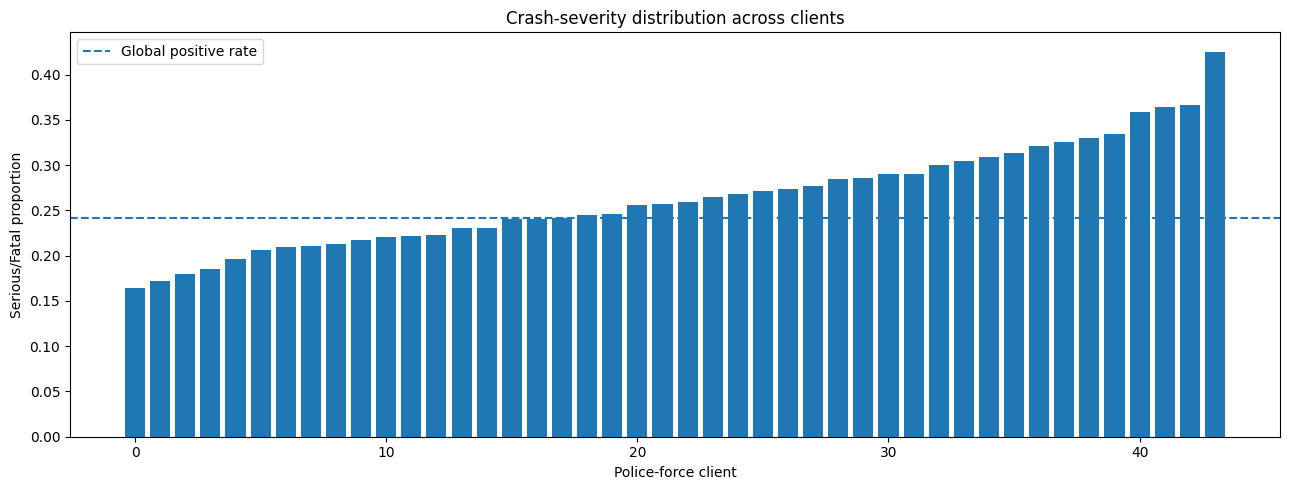

In [11]:
sorted_clients = (
    client_summary
    .sort_values("positive_rate")
    .reset_index()
)

global_positive_rate = df["target_binary"].mean()

plt.figure(figsize=(13, 5))
plt.bar(
    range(len(sorted_clients)),
    sorted_clients["positive_rate"],
)
plt.axhline(
    global_positive_rate,
    linestyle="--",
    label="Global positive rate",
)
plt.xlabel("Police-force client")
plt.ylabel("Serious/Fatal proportion")
plt.title("Crash-severity distribution across clients")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Client size and positive rate

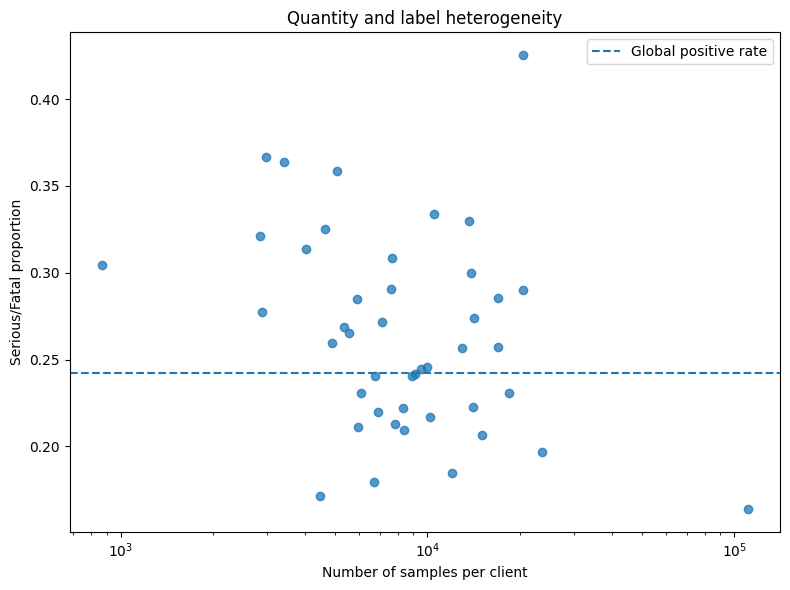

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(
    client_summary["samples"],
    client_summary["positive_rate"],
    alpha=0.75,
)
plt.axhline(
    global_positive_rate,
    linestyle="--",
    label="Global positive rate",
)
plt.xscale("log")
plt.xlabel("Number of samples per client")
plt.ylabel("Serious/Fatal proportion")
plt.title("Quantity and label heterogeneity")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Clients with the lowest and highest positive rates

In [13]:
print("Lowest positive rates")
display(
    client_summary
    .sort_values("positive_rate")
    .head(10)
)

print("Highest positive rates")
display(
    client_summary
    .sort_values("positive_rate")
    .tail(10)
)

Lowest positive rates


,samples,positive_cases,positive_rate
police_force,,,
1,110585,18102,0.163693
62,4450,763,0.171461
54,6677,1200,0.179721
52,12018,2222,0.184889
20,23672,4659,0.196815
43,15062,3111,0.206546
41,8375,1754,0.209433
40,5958,1257,0.210977
7,7849,1670,0.212766


Highest positive rates


,samples,positive_cases,positive_rate
police_force,,,
22,7662,2364,0.308536
3,4035,1265,0.313507
61,2847,915,0.321391
53,4642,1510,0.325291
4,13696,4517,0.329804
14,10495,3506,0.334064
63,5075,1819,0.358424
60,3415,1243,0.363982
11,2969,1089,0.36679


## 12. Save the Day 1 outputs

In [14]:
class_distribution.to_csv(
    results_dir / "class_distribution.csv",
    index=False,
)

client_summary.to_csv(
    results_dir / "client_summary.csv",
)

day1_summary = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "number_of_clients": int(len(client_summary)),
    "global_positive_rate": float(global_positive_rate),
    "smallest_client": int(
        client_summary["samples"].min()
    ),
    "largest_client": int(
        client_summary["samples"].max()
    ),
    "median_client_size": float(
        client_summary["samples"].median()
    ),
    "minimum_client_positive_rate": float(
        client_summary["positive_rate"].min()
    ),
    "maximum_client_positive_rate": float(
        client_summary["positive_rate"].max()
    ),
}

import json

with open(
    results_dir / "day1_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        day1_summary,
        file,
        indent=2,
    )

print(day1_summary)
print("Results saved in:", results_dir)

{'rows': 513801, 'columns': 45, 'number_of_clients': 44, 'global_positive_rate': 0.2420509107611702, 'smallest_client': 871, 'largest_client': 110585, 'median_client_size': 8071.0, 'minimum_client_positive_rate': 0.16369308676583624, 'maximum_client_positive_rate': 0.4253287871407696}
Results saved in: /content/fedsafe-crash/results


## Day 1 conclusion

The data are suitable for a federated learning experiment because police
forces differ in both sample size and crash-severity distribution.

In [15]:
# Day 2 — Data Preparation

In [16]:
if "accident_year" in df.columns:
    df["year"] = pd.to_numeric(
        df["accident_year"],
        errors="coerce"
    )
else:
    df["year"] = pd.to_datetime(
        df["date"],
        dayfirst=True,
        errors="coerce"
    ).dt.year

year_counts = (
    df["year"]
    .value_counts()
    .sort_index()
)

print(year_counts)

year
2021    101087
2022    106004
2023    104258
2024    100927
2025    101525
Name: count, dtype: int64


In [17]:
date = pd.to_datetime(
    df["date"],
    dayfirst=True,
    errors="coerce"
)

time = pd.to_datetime(
    df["time"],
    format="%H:%M",
    errors="coerce"
)

df["month"] = date.dt.month
df["hour"] = time.dt.hour

In [18]:
display(
    df[
        [
            "date",
            "time",
            "year",
            "month",
            "hour"
        ]
    ].head()
)

,date,time,year,month,hour
0,15/02/2025,19:15,2025,2,19
1,22/10/2024,14:48,2024,10,14
2,19/12/2025,06:40,2025,12,6
3,22/04/2025,20:03,2025,4,20
4,28/04/2025,17:40,2025,4,17


In [19]:
candidate_features = [
    "number_of_vehicles",
    "speed_limit",
    "day_of_week",
    "road_type",
    "junction_detail",
    "junction_control",
    "pedestrian_crossing_human_control",
    "pedestrian_crossing_physical_facilities",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "special_conditions_at_site",
    "carriageway_hazards",
    "urban_or_rural_area",
    "month",
    "hour"
]

In [20]:
features = [
    column
    for column in candidate_features
    if column in df.columns
]

print("Number of features:", len(features))

for feature in features:
    print(feature)

Number of features: 14
number_of_vehicles
speed_limit
day_of_week
road_type
junction_detail
junction_control
light_conditions
weather_conditions
road_surface_conditions
special_conditions_at_site
carriageway_hazards
urban_or_rural_area
month
hour


In [21]:
client_column = "police_force"
target_column = "target_binary"

columns_needed = (
    [client_column, "year"]
    + features
    + [target_column]
)

model_data = df[
    columns_needed
].copy()

In [22]:
model_data = model_data.dropna(
    subset=[
        client_column,
        "year",
        target_column
    ]
)

In [23]:
model_data[client_column] = (
    model_data[client_column]
    .astype(int)
)

model_data["year"] = (
    model_data["year"]
    .astype(int)
)

In [24]:
print(model_data.shape)

display(model_data.head())

(513801, 17)


,police_force,year,number_of_vehicles,speed_limit,day_of_week,road_type,junction_detail,junction_control,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,month,hour,target_binary
0,17,2025,1,30,7,6,16,4,4,1,1,-1,0,1,2,19,0
1,17,2024,1,30,3,6,0,-1,1,1,1,-1,0,1,10,14,1
2,11,2025,2,30,6,6,13,4,4,2,2,-1,0,1,12,6,0
3,7,2025,1,30,3,6,0,-1,1,1,1,-1,0,1,4,20,1
4,7,2025,2,30,2,6,16,4,1,1,1,-1,0,1,4,17,0


In [25]:
years = sorted(
    model_data["year"].unique()
)

train_years = years[:-2]
validation_year = years[-2]
test_year = years[-1]

print("Train:", train_years)
print("Validation:", validation_year)
print("Test:", test_year)

Train: [np.int64(2021), np.int64(2022), np.int64(2023)]
Validation: 2024
Test: 2025


In [26]:
train_df = model_data[
    model_data["year"].isin(train_years)
].copy()

val_df = model_data[
    model_data["year"] == validation_year
].copy()

test_df = model_data[
    model_data["year"] == test_year
].copy()

In [27]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (311349, 17)
Validation: (100927, 17)
Test: (101525, 17)


In [28]:
def client_summary(frame, split_name):
    summary = (
        frame
        .groupby("police_force")["target_binary"]
        .agg(
            samples="size",
            positive_cases="sum",
            positive_rate="mean"
        )
        .reset_index()
    )

    summary["split"] = split_name

    return summary


client_split_summary = pd.concat(
    [
        client_summary(train_df, "train"),
        client_summary(val_df, "validation"),
        client_summary(test_df, "test")
    ],
    ignore_index=True
)

display(client_split_summary.head(15))

,police_force,samples,positive_cases,positive_rate,split
0,1,69059,10764,0.155867,train
1,3,2460,770,0.313008,train
2,4,8242,2737,0.33208,train
3,5,6395,1359,0.21251,train
4,6,8342,2256,0.270439,train
5,7,4815,887,0.184216,train
6,10,5544,1323,0.238636,train
7,11,1823,644,0.353264,train
8,12,3928,927,0.235998,train
9,13,12530,3592,0.286672,train


In [29]:
client_presence = (
    client_split_summary
    .pivot(
        index="police_force",
        columns="split",
        values="samples"
    )
    .fillna(0)
    .astype(int)
)

display(client_presence)

print("Number of clients:", len(client_presence))

print(
    "Clients available in all splits:",
    (
        (client_presence["train"] > 0)
        & (client_presence["validation"] > 0)
        & (client_presence["test"] > 0)
    ).sum()
)

split,test,train,validation
police_force,,,
1,20692,69059,20834
3,781,2460,794
4,2723,8242,2731
5,1933,6395,1902
6,2711,8342,2793
7,1559,4815,1475
10,1753,5544,1834
11,575,1823,571
12,1472,3928,1347


Number of clients: 44
Clients available in all splits: 44


In [30]:
print("Smallest train clients:")
display(
    client_split_summary[
        client_split_summary["split"] == "train"
    ]
    .sort_values("samples")
    .head(10)
)

print("Smallest validation clients:")
display(
    client_split_summary[
        client_split_summary["split"] == "validation"
    ]
    .sort_values("samples")
    .head(10)
)

print("Smallest test clients:")
display(
    client_split_summary[
        client_split_summary["split"] == "test"
    ]
    .sort_values("samples")
    .head(10)
)

Smallest train clients:


,police_force,samples,positive_cases,positive_rate,split
33,48,496,145,0.292339,train
40,61,1698,552,0.325088,train
7,11,1823,644,0.353264,train
12,17,1904,485,0.254727,train
14,21,2209,671,0.303757,train
39,60,2359,777,0.329377,train
1,3,2460,770,0.313008,train
16,23,2715,698,0.25709,train
36,53,2755,963,0.349546,train
41,62,2852,478,0.167602,train


Smallest validation clients:


,police_force,samples,positive_cases,positive_rate,split
77,48,166,54,0.325301,validation
56,17,500,144,0.288,validation
83,60,521,213,0.408829,validation
84,61,569,184,0.323374,validation
51,11,571,222,0.388792,validation
45,3,794,245,0.308564,validation
85,62,799,126,0.157697,validation
86,63,1024,429,0.418945,validation
80,53,1030,268,0.260194,validation
60,23,1092,288,0.263736,validation


Smallest test clients:


,police_force,samples,positive_cases,positive_rate,split
121,48,209,66,0.315789,test
100,17,488,173,0.354508,test
127,60,535,253,0.472897,test
95,11,575,223,0.387826,test
128,61,580,179,0.308621,test
89,3,781,250,0.320102,test
129,62,799,159,0.198999,test
124,53,857,279,0.325554,test
104,23,1082,284,0.262477,test
130,63,1089,470,0.431589,test


In [31]:
numerical_features = [
    "number_of_vehicles",
    "speed_limit"
]

categorical_features = [
    feature
    for feature in features
    if feature not in numerical_features
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['number_of_vehicles', 'speed_limit']

Categorical features:
['day_of_week', 'road_type', 'junction_detail', 'junction_control', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'month', 'hour']


In [32]:
for feature in features:
    print(f"\n{feature}")
    print(
        train_df[feature]
        .value_counts(dropna=False)
        .sort_index()
        .head(30)
    )


number_of_vehicles
number_of_vehicles
1      89810
2     193824
3      21424
4       4510
5       1157
6        376
7        141
8         52
9         21
10        14
11         6
12         5
13         3
14         1
15         1
16         2
17         2
Name: count, dtype: int64

speed_limit
speed_limit
20     49170
30    167395
40     26915
50     13376
60     37285
70     17208
Name: count, dtype: int64

day_of_week
day_of_week
1    35196
2    42317
3    45052
4    46387
5    47189
6    52056
7    43152
Name: count, dtype: int64

road_type
road_type
1     18179
2      6928
3     46838
6    225297
7      5568
9      8539
Name: count, dtype: int64

junction_detail
junction_detail
-1       6276
 0     160549
 13     86395
 16     28621
 17      4784
 18      6747
 19     17977
Name: count, dtype: int64

junction_control
junction_control
-1    130829
 1      1411
 2     34824
 3      2174
 4    136335
 9      5776
Name: count, dtype: int64

light_conditions
light_conditions
-1     

In [33]:
numerical_features = [
    "number_of_vehicles",
    "speed_limit"
]

categorical_features = [
    feature
    for feature in features
    if feature not in numerical_features
]

print("Numerical:")
print(numerical_features)

print("\nCategorical:")
print(categorical_features)

Numerical:
['number_of_vehicles', 'speed_limit']

Categorical:
['day_of_week', 'road_type', 'junction_detail', 'junction_control', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'month', 'hour']


In [34]:
X_train = train_df[features]
y_train = train_df["target_binary"].astype(int)

X_val = val_df[features]
y_val = val_df["target_binary"].astype(int)

X_test = test_df[features]
y_test = test_df["target_binary"].astype(int)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (311349, 14) (311349,)
Validation: (100927, 14) (100927,)
Test: (101525, 14) (101525,)


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    sparse_threshold=1.0
)

In [36]:
X_train_processed = preprocessor.fit_transform(X_train)

In [37]:
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [38]:
print(
    "Train processed:",
    X_train_processed.shape
)

print(
    "Validation processed:",
    X_val_processed.shape
)

print(
    "Test processed:",
    X_test_processed.shape
)

Train processed: (311349, 115)
Validation processed: (100927, 115)
Test processed: (101525, 115)


In [39]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "Original features:",
    len(features)
)

print(
    "Features after encoding:",
    len(feature_names)
)

print("\nFirst 30 encoded features:")

for name in feature_names[:30]:
    print(name)

Original features: 14
Features after encoding: 115

First 30 encoded features:
numeric__number_of_vehicles
numeric__speed_limit
categorical__day_of_week_1
categorical__day_of_week_2
categorical__day_of_week_3
categorical__day_of_week_4
categorical__day_of_week_5
categorical__day_of_week_6
categorical__day_of_week_7
categorical__road_type_1
categorical__road_type_2
categorical__road_type_3
categorical__road_type_6
categorical__road_type_7
categorical__road_type_9
categorical__junction_detail_-1
categorical__junction_detail_0
categorical__junction_detail_13
categorical__junction_detail_16
categorical__junction_detail_17
categorical__junction_detail_18
categorical__junction_detail_19
categorical__junction_control_-1
categorical__junction_control_1
categorical__junction_control_2
categorical__junction_control_3
categorical__junction_control_4
categorical__junction_control_9
categorical__light_conditions_-1
categorical__light_conditions_1


In [41]:
from sklearn.linear_model import LogisticRegression

central_model = LogisticRegression(
    solver="saga",
    max_iter=300,
    random_state=42
)

central_model.fit(
    X_train_processed,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=300, random_state=42, solver='saga')

In [42]:
val_prob = central_model.predict_proba(
    X_val_processed
)[:, 1]

test_prob = central_model.predict_proba(
    X_test_processed
)[:, 1]

In [43]:
val_pred = (val_prob >= 0.5).astype(int)
test_pred = (test_prob >= 0.5).astype(int)

In [44]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


def evaluate_model(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_prob
        ),
        "pr_auc": average_precision_score(
            y_true,
            y_prob
        )
    }

In [45]:
val_results = evaluate_model(
    y_val,
    val_pred,
    val_prob
)

test_results = evaluate_model(
    y_test,
    test_pred,
    test_prob
)

print("Validation")
for metric, value in val_results.items():
    print(f"{metric}: {value:.4f}")

print("\nTest")
for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")

Validation
accuracy: 0.7516
balanced_accuracy: 0.5001
precision: 0.4286
recall: 0.0002
f1: 0.0005
roc_auc: 0.5499
pr_auc: 0.2766

Test
accuracy: 0.7375
balanced_accuracy: 0.5000
precision: 0.2105
recall: 0.0002
f1: 0.0003
roc_auc: 0.5589
pr_auc: 0.2961


In [46]:
from sklearn.metrics import confusion_matrix

print("Validation confusion matrix")
print(confusion_matrix(y_val, val_pred))

print("\nTest confusion matrix")
print(confusion_matrix(y_test, test_pred))

Validation confusion matrix
[[75850     8]
 [25063     6]]

Test confusion matrix
[[74866    15]
 [26640     4]]


In [ ]:
balanced_model = LogisticRegression(
    solver="saga",
    max_iter=500,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(
    X_train_processed,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42,
                   solver='saga')

In [ ]:
balanced_val_prob = balanced_model.predict_proba(
    X_val_processed
)[:, 1]

balanced_test_prob = balanced_model.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
balanced_val_pred = (
    balanced_val_prob >= 0.5
).astype(int)

balanced_test_pred = (
    balanced_test_prob >= 0.5
).astype(int)

In [ ]:
balanced_val_results = evaluate_model(
    y_val,
    balanced_val_pred,
    balanced_val_prob
)

balanced_test_results = evaluate_model(
    y_test,
    balanced_test_pred,
    balanced_test_prob
)

print("Validation")
for metric, value in balanced_val_results.items():
    print(f"{metric}: {value:.4f}")

print("\nTest")
for metric, value in balanced_test_results.items():
    print(f"{metric}: {value:.4f}")

Validation
accuracy: 0.6721
balanced_accuracy: 0.5139
precision: 0.2775
recall: 0.1998
f1: 0.2323
roc_auc: 0.5435
pr_auc: 0.2727

Test
accuracy: 0.6944
balanced_accuracy: 0.5080
precision: 0.2923
recall: 0.1157
f1: 0.1658
roc_auc: 0.5553
pr_auc: 0.2927


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.05, 0.96, 0.01)

threshold_results = []

for threshold in thresholds:
    predictions = (
        balanced_val_prob >= threshold
    ).astype(int)

    score = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    threshold_results.append(
        (threshold, score)
    )

best_threshold, best_f1 = max(
    threshold_results,
    key=lambda x: x[1]
)

print("Best threshold:", round(best_threshold, 2))
print("Validation F1:", round(best_f1, 4))

Best threshold: 0.23
Validation F1: 0.4059


In [ ]:
val_pred_tuned = (
    balanced_val_prob >= best_threshold
).astype(int)

test_pred_tuned = (
    balanced_test_prob >= best_threshold
).astype(int)

In [ ]:
tuned_val_results = evaluate_model(
    y_val,
    val_pred_tuned,
    balanced_val_prob
)

tuned_test_results = evaluate_model(
    y_test,
    test_pred_tuned,
    balanced_test_prob
)

print("Validation")
for metric, value in tuned_val_results.items():
    print(f"{metric}: {value:.4f}")

print("\nTest")
for metric, value in tuned_test_results.items():
    print(f"{metric}: {value:.4f}")

Validation
accuracy: 0.3231
balanced_accuracy: 0.5266
precision: 0.2595
recall: 0.9309
f1: 0.4059
roc_auc: 0.5435
pr_auc: 0.2727

Test
accuracy: 0.3456
balanced_accuracy: 0.5243
precision: 0.2733
recall: 0.9004
f1: 0.4193
roc_auc: 0.5553
pr_auc: 0.2927


In [ ]:
print("Selected threshold:", best_threshold)

Selected threshold: 0.23000000000000004


MLP

In [48]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader


def to_dense_float32(x):
    if hasattr(x, "toarray"):
        x = x.toarray()

    return x.astype(np.float32)


X_train_nn = to_dense_float32(X_train_processed)
X_val_nn = to_dense_float32(X_val_processed)
X_test_nn = to_dense_float32(X_test_processed)

y_train_nn = y_train.to_numpy(dtype=np.float32)
y_val_nn = y_val.to_numpy(dtype=np.float32)
y_test_nn = y_test.to_numpy(dtype=np.float32)

print(X_train_nn.shape)
print(X_val_nn.shape)
print(X_test_nn.shape)

(311349, 115)
(100927, 115)
(101525, 115)


In [49]:
batch_size = 512

train_dataset = TensorDataset(
    torch.from_numpy(X_train_nn),
    torch.from_numpy(y_train_nn)
)

val_dataset = TensorDataset(
    torch.from_numpy(X_val_nn),
    torch.from_numpy(y_val_nn)
)

test_dataset = TensorDataset(
    torch.from_numpy(X_test_nn),
    torch.from_numpy(y_test_nn)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))

Train batches: 609


In [50]:
import torch.nn as nn


class CrashMLP(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

In [51]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CrashMLP(
    input_dim=X_train_nn.shape[1]
).to(device)

print(device)
print(model)

cuda
CrashMLP(
  (network): Sequential(
    (0): Linear(in_features=115, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [52]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [53]:
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [54]:
def train_one_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    device
):
    model.train()

    total_loss = 0.0

    for features_batch, targets_batch in data_loader:

        features_batch = features_batch.to(device)
        targets_batch = targets_batch.to(device)

        optimizer.zero_grad()

        logits = model(features_batch)

        loss = criterion(
            logits,
            targets_batch
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item()
            * features_batch.size(0)
        )

    return total_loss / len(data_loader.dataset)

In [55]:
def predict_probabilities(
    model,
    data_loader,
    device
):
    model.eval()

    probabilities = []

    with torch.no_grad():

        for features_batch, _ in data_loader:

            features_batch = features_batch.to(device)

            logits = model(features_batch)

            probs = torch.sigmoid(logits)

            probabilities.append(
                probs.cpu().numpy()
            )

    return np.concatenate(probabilities)

In [56]:
epochs = 10

training_history = []

for epoch in range(epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_prob_mlp = predict_probabilities(
        model,
        val_loader,
        device
    )

    val_pred_mlp = (
        val_prob_mlp >= 0.5
    ).astype(int)

    val_f1 = f1_score(
        y_val,
        val_pred_mlp,
        zero_division=0
    )

    training_history.append(
        {
            "epoch": epoch + 1,
            "loss": train_loss,
            "val_f1": val_f1
        }
    )

    print(
        f"Epoch {epoch + 1:02d} | "
        f"loss: {train_loss:.4f} | "
        f"val_f1: {val_f1:.4f}"
    )

Epoch 01 | loss: 0.5316 | val_f1: 0.0001
Epoch 02 | loss: 0.5224 | val_f1: 0.0005
Epoch 03 | loss: 0.5214 | val_f1: 0.0002
Epoch 04 | loss: 0.5209 | val_f1: 0.0003
Epoch 05 | loss: 0.5201 | val_f1: 0.0003
Epoch 06 | loss: 0.5197 | val_f1: 0.0007
Epoch 07 | loss: 0.5194 | val_f1: 0.0006
Epoch 08 | loss: 0.5188 | val_f1: 0.0015
Epoch 09 | loss: 0.5187 | val_f1: 0.0016
Epoch 10 | loss: 0.5182 | val_f1: 0.0024


In [57]:
from sklearn.metrics import roc_auc_score, average_precision_score

val_prob_mlp = predict_probabilities(
    model,
    val_loader,
    device
)

print("Min probability:", val_prob_mlp.min())
print("Mean probability:", val_prob_mlp.mean())
print("Max probability:", val_prob_mlp.max())

print(
    "Predicted positive rate:",
    (val_prob_mlp >= 0.5).mean()
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val, val_prob_mlp)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, val_prob_mlp)
)

Min probability: 0.0048106564
Mean probability: 0.22077738
Max probability: 0.5975889
Predicted positive rate: 0.0006737542976606854
ROC-AUC: 0.6269566294162232
PR-AUC: 0.3421102646267519


In [58]:
from sklearn.metrics import roc_auc_score, average_precision_score

val_prob_mlp = predict_probabilities(
    model,
    val_loader,
    device
)

print("Min probability:", val_prob_mlp.min())
print("Mean probability:", val_prob_mlp.mean())
print("Max probability:", val_prob_mlp.max())

print(
    "Predicted positive rate:",
    (val_prob_mlp >= 0.5).mean()
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val, val_prob_mlp)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, val_prob_mlp)
)

Min probability: 0.0048106564
Mean probability: 0.22077738
Max probability: 0.5975889
Predicted positive rate: 0.0006737542976606854
ROC-AUC: 0.6269566294162232
PR-AUC: 0.3421102646267519


In [59]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

pos_weight_value = (
    negative_count / positive_count
)

print("Negative:", negative_count)
print("Positive:", positive_count)
print("pos_weight:", pos_weight_value)

Negative: 238696
Positive: 72653
pos_weight: 3.2854252405268882


In [60]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [61]:
weighted_model = CrashMLP(
    input_dim=X_train_nn.shape[1]
).to(device)

In [62]:
pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=device
)

weighted_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

weighted_optimizer = torch.optim.Adam(
    weighted_model.parameters(),
    lr=0.001
)

In [63]:
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    average_precision_score
)

weighted_history = []

for epoch in range(10):

    train_loss = train_one_epoch(
        weighted_model,
        train_loader,
        weighted_optimizer,
        weighted_criterion,
        device
    )

    val_prob = predict_probabilities(
        weighted_model,
        val_loader,
        device
    )

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    val_f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    val_auc = roc_auc_score(
        y_val,
        val_prob
    )

    val_pr_auc = average_precision_score(
        y_val,
        val_prob
    )

    weighted_history.append({
        "epoch": epoch + 1,
        "loss": train_loss,
        "f1": val_f1,
        "roc_auc": val_auc,
        "pr_auc": val_pr_auc
    })

    print(
        f"Epoch {epoch + 1:02d} | "
        f"loss: {train_loss:.4f} | "
        f"f1: {val_f1:.4f} | "
        f"roc_auc: {val_auc:.4f} | "
        f"pr_auc: {val_pr_auc:.4f}"
    )

Epoch 01 | loss: 1.0228 | f1: 0.4193 | roc_auc: 0.6292 | pr_auc: 0.3454
Epoch 02 | loss: 1.0145 | f1: 0.4193 | roc_auc: 0.6281 | pr_auc: 0.3435
Epoch 03 | loss: 1.0126 | f1: 0.4217 | roc_auc: 0.6290 | pr_auc: 0.3459
Epoch 04 | loss: 1.0112 | f1: 0.4182 | roc_auc: 0.6267 | pr_auc: 0.3417
Epoch 05 | loss: 1.0103 | f1: 0.4146 | roc_auc: 0.6252 | pr_auc: 0.3422
Epoch 06 | loss: 1.0093 | f1: 0.4080 | roc_auc: 0.6250 | pr_auc: 0.3406
Epoch 07 | loss: 1.0088 | f1: 0.4076 | roc_auc: 0.6249 | pr_auc: 0.3407
Epoch 08 | loss: 1.0081 | f1: 0.4161 | roc_auc: 0.6236 | pr_auc: 0.3395
Epoch 09 | loss: 1.0075 | f1: 0.4060 | roc_auc: 0.6213 | pr_auc: 0.3394
Epoch 10 | loss: 1.0065 | f1: 0.4061 | roc_auc: 0.6217 | pr_auc: 0.3393


New Model

In [64]:
import random
import copy
import numpy as np
import torch
import torch.nn as nn

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

weighted_model = CrashMLP(
    input_dim=X_train_nn.shape[1]
).to(device)

print(weighted_model)

CrashMLP(
  (network): Sequential(
    (0): Linear(in_features=115, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [65]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

pos_weight_value = negative_count / positive_count

print("Negative:", negative_count)
print("Positive:", positive_count)
print("pos_weight:", pos_weight_value)

pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=device
)

weighted_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

weighted_optimizer = torch.optim.Adam(
    weighted_model.parameters(),
    lr=0.001
)

Negative: 238696
Positive: 72653
pos_weight: 3.2854252405268882


In [66]:
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    average_precision_score
)

best_pr_auc = -1
best_epoch = None
best_state = None

patience = 3
epochs_without_improvement = 0

history = []

for epoch in range(20):

    train_loss = train_one_epoch(
        weighted_model,
        train_loader,
        weighted_optimizer,
        weighted_criterion,
        device
    )

    val_prob = predict_probabilities(
        weighted_model,
        val_loader,
        device
    )

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    val_f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    val_auc = roc_auc_score(
        y_val,
        val_prob
    )

    val_pr_auc = average_precision_score(
        y_val,
        val_prob
    )

    history.append({
        "epoch": epoch + 1,
        "loss": train_loss,
        "f1": val_f1,
        "roc_auc": val_auc,
        "pr_auc": val_pr_auc
    })

    print(
        f"Epoch {epoch + 1:02d} | "
        f"loss: {train_loss:.4f} | "
        f"f1: {val_f1:.4f} | "
        f"roc_auc: {val_auc:.4f} | "
        f"pr_auc: {val_pr_auc:.4f}"
    )

    if val_pr_auc > best_pr_auc:

        best_pr_auc = val_pr_auc
        best_epoch = epoch + 1

        best_state = copy.deepcopy(
            weighted_model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("\nEarly stopping")
        break

Epoch 01 | loss: 1.0228 | f1: 0.4193 | roc_auc: 0.6292 | pr_auc: 0.3454
Epoch 02 | loss: 1.0145 | f1: 0.4193 | roc_auc: 0.6281 | pr_auc: 0.3435
Epoch 03 | loss: 1.0126 | f1: 0.4217 | roc_auc: 0.6290 | pr_auc: 0.3459
Epoch 04 | loss: 1.0112 | f1: 0.4182 | roc_auc: 0.6267 | pr_auc: 0.3417
Epoch 05 | loss: 1.0103 | f1: 0.4146 | roc_auc: 0.6252 | pr_auc: 0.3422
Epoch 06 | loss: 1.0093 | f1: 0.4080 | roc_auc: 0.6250 | pr_auc: 0.3406

Early stopping


In [67]:
weighted_model.load_state_dict(
    best_state
)

print("Best epoch:", best_epoch)
print(
    "Best validation PR-AUC:",
    round(best_pr_auc, 4)
)

Best epoch: 3
Best validation PR-AUC: 0.3459


In [68]:
best_val_prob = predict_probabilities(
    weighted_model,
    val_loader,
    device
)

thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        best_val_prob >= threshold
    ).astype(int)

    score = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    threshold_results.append(
        (threshold, score)
    )

best_threshold, best_threshold_f1 = max(
    threshold_results,
    key=lambda x: x[1]
)

print(
    "Best threshold:",
    round(best_threshold, 2)
)

print(
    "Validation F1:",
    round(best_threshold_f1, 4)
)

Best threshold: 0.45
Validation F1: 0.4281


In [69]:
test_prob_mlp = predict_probabilities(
    weighted_model,
    test_loader,
    device
)

test_pred_mlp = (
    test_prob_mlp >= best_threshold
).astype(int)

test_results_mlp = evaluate_model(
    y_test,
    test_pred_mlp,
    test_prob_mlp
)

print("Weighted MLP — Test")

for metric, value in test_results_mlp.items():
    print(f"{metric}: {value:.4f}")

Weighted MLP — Test
accuracy: 0.5059
balanced_accuracy: 0.5740
precision: 0.3095
recall: 0.7175
f1: 0.4325
roc_auc: 0.6147
pr_auc: 0.3531


In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    test_pred_mlp
)

print(cm)

[[32240 42641]
 [ 7527 19117]]


In [71]:
print(
    "Predicted positive rate:",
    test_pred_mlp.mean()
)

print(
    "Actual positive rate:",
    y_test.mean()
)

print(
    "Threshold:",
    best_threshold
)

Predicted positive rate: 0.608303373553312
Actual positive rate: 0.2624378231962571
Threshold: 0.45000000000000007


In [72]:
test_pred_05 = (
    test_prob_mlp >= 0.5
).astype(int)

test_results_05 = evaluate_model(
    y_test,
    test_pred_05,
    test_prob_mlp
)

print("Weighted MLP — threshold 0.50")

for metric, value in test_results_05.items():
    print(f"{metric}: {value:.4f}")

print("\nPredicted positive rate:")
print(test_pred_05.mean())

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_test,
        test_pred_05
    )
)

Weighted MLP — threshold 0.50
accuracy: 0.5778
balanced_accuracy: 0.5833
precision: 0.3307
recall: 0.5948
f1: 0.4251
roc_auc: 0.6147
pr_auc: 0.3531

Predicted positive rate:
0.47197242058606254

Confusion matrix:
[[42812 32069]
 [10796 15848]]


In [73]:
train_client_stats = (
    train_df
    .groupby("police_force")["target_binary"]
    .agg(
        samples="size",
        positive_rate="mean"
    )
)

largest_client = (
    train_client_stats["samples"]
    .idxmax()
)

smallest_client = (
    train_client_stats["samples"]
    .idxmin()
)

highest_positive_client = (
    train_client_stats["positive_rate"]
    .idxmax()
)

lowest_positive_client = (
    train_client_stats["positive_rate"]
    .idxmin()
)

median_size = (
    train_client_stats["samples"]
    .median()
)

median_client = (
    train_client_stats["samples"]
    .sub(median_size)
    .abs()
    .idxmin()
)

development_clients = list(
    dict.fromkeys([
        largest_client,
        smallest_client,
        highest_positive_client,
        lowest_positive_client,
        median_client
    ])
)

print("Development clients:")
print(development_clients)

display(
    train_client_stats.loc[
        development_clients
    ]
)

Development clients:
[np.int64(1), np.int64(48), np.int64(99), np.int64(52), np.int64(7)]


,samples,positive_rate
police_force,,
1,69059,0.155867
48,496,0.292339
99,12259,0.415776
52,7007,0.150706
7,4815,0.184216


In [74]:
client_id = 1

train_mask = (
    train_df["police_force"].to_numpy()
    == client_id
)

val_mask = (
    val_df["police_force"].to_numpy()
    == client_id
)

test_mask = (
    test_df["police_force"].to_numpy()
    == client_id
)

X_client_train = X_train_nn[train_mask]
y_client_train = y_train_nn[train_mask]

X_client_val = X_val_nn[val_mask]
y_client_val = y_val_nn[val_mask]

X_client_test = X_test_nn[test_mask]
y_client_test = y_test_nn[test_mask]

print("Client:", client_id)

print(
    "Train:",
    X_client_train.shape,
    y_client_train.mean()
)

print(
    "Validation:",
    X_client_val.shape,
    y_client_val.mean()
)

print(
    "Test:",
    X_client_test.shape,
    y_client_test.mean()
)

Client: 1
Train: (69059, 115) 0.15586673
Validation: (20834, 115) 0.17029855
Test: (20692, 115) 0.18316257


In [75]:
client_train_dataset = TensorDataset(
    torch.from_numpy(X_client_train),
    torch.from_numpy(y_client_train)
)

client_val_dataset = TensorDataset(
    torch.from_numpy(X_client_val),
    torch.from_numpy(y_client_val)
)

client_train_loader = DataLoader(
    client_train_dataset,
    batch_size=256,
    shuffle=True
)

client_val_loader = DataLoader(
    client_val_dataset,
    batch_size=512,
    shuffle=False
)

In [76]:
client_negative = (
    y_client_train == 0
).sum()

client_positive = (
    y_client_train == 1
).sum()

client_pos_weight_value = (
    client_negative
    / client_positive
)

print("Negative:", client_negative)
print("Positive:", client_positive)
print(
    "Local pos_weight:",
    client_pos_weight_value
)

Negative: 58295
Positive: 10764
Local pos_weight: 5.415737643998513


In [77]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

local_model = CrashMLP(
    input_dim=X_client_train.shape[1]
).to(device)

local_pos_weight = torch.tensor(
    [client_pos_weight_value],
    dtype=torch.float32,
    device=device
)

local_criterion = nn.BCEWithLogitsLoss(
    pos_weight=local_pos_weight
)

local_optimizer = torch.optim.Adam(
    local_model.parameters(),
    lr=0.001
)

In [78]:
best_local_pr_auc = -1
best_local_epoch = None
best_local_state = None

patience = 3
epochs_without_improvement = 0

for epoch in range(20):

    train_loss = train_one_epoch(
        local_model,
        client_train_loader,
        local_optimizer,
        local_criterion,
        device
    )

    val_prob = predict_probabilities(
        local_model,
        client_val_loader,
        device
    )

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    val_f1 = f1_score(
        y_client_val,
        val_pred,
        zero_division=0
    )

    val_auc = roc_auc_score(
        y_client_val,
        val_prob
    )

    val_pr_auc = average_precision_score(
        y_client_val,
        val_prob
    )

    print(
        f"Epoch {epoch + 1:02d} | "
        f"loss: {train_loss:.4f} | "
        f"f1: {val_f1:.4f} | "
        f"roc_auc: {val_auc:.4f} | "
        f"pr_auc: {val_pr_auc:.4f}"
    )

    if val_pr_auc > best_local_pr_auc:

        best_local_pr_auc = val_pr_auc
        best_local_epoch = epoch + 1

        best_local_state = copy.deepcopy(
            local_model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("\nEarly stopping")
        break

Epoch 01 | loss: 1.1242 | f1: 0.3270 | roc_auc: 0.6440 | pr_auc: 0.2523
Epoch 02 | loss: 1.1029 | f1: 0.3330 | roc_auc: 0.6522 | pr_auc: 0.2564
Epoch 03 | loss: 1.0971 | f1: 0.3425 | roc_auc: 0.6519 | pr_auc: 0.2573
Epoch 04 | loss: 1.0924 | f1: 0.3425 | roc_auc: 0.6522 | pr_auc: 0.2573
Epoch 05 | loss: 1.0909 | f1: 0.3364 | roc_auc: 0.6505 | pr_auc: 0.2542
Epoch 06 | loss: 1.0881 | f1: 0.3386 | roc_auc: 0.6493 | pr_auc: 0.2552

Early stopping


In [79]:
local_model.load_state_dict(
    best_local_state
)

print(
    "Best local epoch:",
    best_local_epoch
)

print(
    "Best local validation PR-AUC:",
    round(best_local_pr_auc, 4)
)

Best local epoch: 3
Best local validation PR-AUC: 0.2573


In [80]:
def train_local_client(client_id, max_epochs=20, patience=3):

    train_mask = (
        train_df["police_force"].to_numpy()
        == client_id
    )

    val_mask = (
        val_df["police_force"].to_numpy()
        == client_id
    )

    test_mask = (
        test_df["police_force"].to_numpy()
        == client_id
    )

    X_local_train = X_train_nn[train_mask]
    y_local_train = y_train_nn[train_mask]

    X_local_val = X_val_nn[val_mask]
    y_local_val = y_val_nn[val_mask]

    X_local_test = X_test_nn[test_mask]
    y_local_test = y_test_nn[test_mask]

    train_dataset = TensorDataset(
        torch.from_numpy(X_local_train),
        torch.from_numpy(y_local_train)
    )

    val_dataset = TensorDataset(
        torch.from_numpy(X_local_val),
        torch.from_numpy(y_local_val)
    )

    test_dataset = TensorDataset(
        torch.from_numpy(X_local_test),
        torch.from_numpy(y_local_test)
    )

    train_loader_local = DataLoader(
        train_dataset,
        batch_size=256,
        shuffle=True
    )

    val_loader_local = DataLoader(
        val_dataset,
        batch_size=512,
        shuffle=False
    )

    test_loader_local = DataLoader(
        test_dataset,
        batch_size=512,
        shuffle=False
    )

    negative = (y_local_train == 0).sum()
    positive = (y_local_train == 1).sum()

    local_weight = negative / positive

    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    model = CrashMLP(
        input_dim=X_local_train.shape[1]
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [local_weight],
            dtype=torch.float32,
            device=device
        )
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    best_pr_auc = -1
    best_epoch = None
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):

        train_loss = train_one_epoch(
            model,
            train_loader_local,
            optimizer,
            criterion,
            device
        )

        val_prob = predict_probabilities(
            model,
            val_loader_local,
            device
        )

        val_pr_auc = average_precision_score(
            y_local_val,
            val_prob
        )

        if val_pr_auc > best_pr_auc:

            best_pr_auc = val_pr_auc
            best_epoch = epoch + 1
            best_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)

    return {
        "client_id": int(client_id),
        "model": model,
        "train_samples": len(y_local_train),
        "val_samples": len(y_local_val),
        "test_samples": len(y_local_test),
        "train_positive_rate": float(
            y_local_train.mean()
        ),
        "best_epoch": best_epoch,
        "best_val_pr_auc": best_pr_auc,
        "val_loader": val_loader_local,
        "test_loader": test_loader_local,
        "y_val": y_local_val,
        "y_test": y_local_test
    }

In [81]:
local_models = {}

for client_id in development_clients:

    print(
        f"\nTraining client {client_id}"
    )

    result = train_local_client(
        client_id
    )

    local_models[int(client_id)] = result

    print(
        "Best epoch:",
        result["best_epoch"]
    )

    print(
        "Validation PR-AUC:",
        round(
            result["best_val_pr_auc"],
            4
        )
    )


Training client 1
Best epoch: 3
Validation PR-AUC: 0.2573

Training client 48
Best epoch: 20
Validation PR-AUC: 0.5256

Training client 99
Best epoch: 9
Validation PR-AUC: 0.5516

Training client 52
Best epoch: 8
Validation PR-AUC: 0.2379

Training client 7
Best epoch: 9
Validation PR-AUC: 0.3397


In [82]:
for client_id, result in local_models.items():

    val_prob = predict_probabilities(
        result["model"],
        result["val_loader"],
        device
    )

    thresholds = np.arange(
        0.05,
        0.96,
        0.01
    )

    scores = []

    for threshold in thresholds:

        val_pred = (
            val_prob >= threshold
        ).astype(int)

        score = f1_score(
            result["y_val"],
            val_pred,
            zero_division=0
        )

        scores.append(
            (threshold, score)
        )

    best_threshold, best_f1 = max(
        scores,
        key=lambda x: x[1]
    )

    result["best_threshold"] = float(
        best_threshold
    )

    result["best_val_f1"] = float(
        best_f1
    )

    print(
        f"Client {client_id} | "
        f"threshold: {best_threshold:.2f} | "
        f"val F1: {best_f1:.4f}"
    )

Client 1 | threshold: 0.49 | val F1: 0.3430
Client 48 | threshold: 0.49 | val F1: 0.5068
Client 99 | threshold: 0.34 | val F1: 0.6175
Client 52 | threshold: 0.52 | val F1: 0.3258
Client 7 | threshold: 0.43 | val F1: 0.4334


In [83]:
local_test_results = []

for client_id, result in local_models.items():

    test_prob = predict_probabilities(
        result["model"],
        result["test_loader"],
        device
    )

    threshold = result[
        "best_threshold"
    ]

    test_pred = (
        test_prob >= threshold
    ).astype(int)

    metrics = evaluate_model(
        result["y_test"],
        test_pred,
        test_prob
    )

    local_test_results.append({
        "client": client_id,
        "train_samples": result[
            "train_samples"
        ],
        "positive_rate": result[
            "train_positive_rate"
        ],
        "best_epoch": result[
            "best_epoch"
        ],
        "threshold": threshold,
        **metrics
    })

In [84]:
import pandas as pd

local_results_df = pd.DataFrame(
    local_test_results
)

display(
    local_results_df.round(4)
)

,client,train_samples,positive_rate,best_epoch,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,1,69059,0.1559,3,0.49,0.5286,0.5796,0.2281,0.6602,0.3390,0.6212,0.2547
1,48,496,0.2923,20,0.49,0.5885,0.5728,0.3889,0.5303,0.4487,0.6034,0.4406
2,99,12259,0.4158,9,0.34,0.5112,0.5498,0.4693,0.8663,0.6088,0.6099,0.5315
3,52,7007,0.1507,8,0.52,0.5920,0.5588,0.3586,0.4772,0.4095,0.5793,0.3576
4,7,4815,0.1842,9,0.43,0.4695,0.5737,0.3133,0.8014,0.4505,0.6047,0.3546


In [85]:
def get_client_train_loader(client_id, batch_size=256):

    mask = (
        train_df["police_force"].to_numpy()
        == client_id
    )

    X_local = X_train_nn[mask]
    y_local = y_train_nn[mask]

    dataset = TensorDataset(
        torch.from_numpy(X_local),
        torch.from_numpy(y_local)
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    return loader, y_local

In [86]:
def train_federated_client(
    global_state,
    client_id,
    local_epochs=1
):

    loader, y_local = get_client_train_loader(
        client_id
    )

    model = CrashMLP(
        input_dim=X_train_nn.shape[1]
    ).to(device)

    model.load_state_dict(
        copy.deepcopy(global_state)
    )

    negative = (y_local == 0).sum()
    positive = (y_local == 1).sum()

    local_pos_weight = (
        negative / positive
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [local_pos_weight],
            dtype=torch.float32,
            device=device
        )
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for _ in range(local_epochs):

        train_one_epoch(
            model,
            loader,
            optimizer,
            criterion,
            device
        )

    return (
        copy.deepcopy(model.state_dict()),
        len(y_local)
    )

In [87]:
def fedavg(client_states, client_sizes):

    total_samples = sum(client_sizes)

    averaged_state = copy.deepcopy(
        client_states[0]
    )

    for key in averaged_state.keys():

        averaged_state[key] = (
            client_states[0][key]
            * (
                client_sizes[0]
                / total_samples
            )
        )

        for i in range(
            1,
            len(client_states)
        ):

            averaged_state[key] += (
                client_states[i][key]
                * (
                    client_sizes[i]
                    / total_samples
                )
            )

    return averaged_state

In [88]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [89]:
global_model = CrashMLP(
    input_dim=X_train_nn.shape[1]
).to(device)

global_state = copy.deepcopy(
    global_model.state_dict()
)

In [90]:
def evaluate_global_model(
    model,
    loader,
    y_true
):

    probabilities = predict_probabilities(
        model,
        loader,
        device
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    return {
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        ),
        "pr_auc": average_precision_score(
            y_true,
            probabilities
        )
    }

In [91]:
federated_history = []

num_rounds = 20

for round_number in range(num_rounds):

    client_states = []
    client_sizes = []

    for client_id in development_clients:

        local_state, local_size = (
            train_federated_client(
                global_state,
                client_id,
                local_epochs=1
            )
        )

        client_states.append(
            local_state
        )

        client_sizes.append(
            local_size
        )

    global_state = fedavg(
        client_states,
        client_sizes
    )

    global_model.load_state_dict(
        global_state
    )

    metrics = evaluate_global_model(
        global_model,
        val_loader,
        y_val
    )

    federated_history.append({
        "round": round_number + 1,
        **metrics
    })

    print(
        f"Round {round_number + 1:02d} | "
        f"F1: {metrics['f1']:.4f} | "
        f"ROC-AUC: {metrics['roc_auc']:.4f} | "
        f"PR-AUC: {metrics['pr_auc']:.4f}"
    )

Round 01 | F1: 0.4123 | ROC-AUC: 0.5993 | PR-AUC: 0.3093
Round 02 | F1: 0.4134 | ROC-AUC: 0.6057 | PR-AUC: 0.3130
Round 03 | F1: 0.4066 | ROC-AUC: 0.6055 | PR-AUC: 0.3145
Round 04 | F1: 0.4159 | ROC-AUC: 0.6058 | PR-AUC: 0.3148
Round 05 | F1: 0.4134 | ROC-AUC: 0.6038 | PR-AUC: 0.3149
Round 06 | F1: 0.4099 | ROC-AUC: 0.6052 | PR-AUC: 0.3163
Round 07 | F1: 0.4089 | ROC-AUC: 0.6045 | PR-AUC: 0.3156
Round 08 | F1: 0.4082 | ROC-AUC: 0.6015 | PR-AUC: 0.3136
Round 09 | F1: 0.4131 | ROC-AUC: 0.6048 | PR-AUC: 0.3162
Round 10 | F1: 0.4042 | ROC-AUC: 0.6043 | PR-AUC: 0.3160
Round 11 | F1: 0.4063 | ROC-AUC: 0.6023 | PR-AUC: 0.3153
Round 12 | F1: 0.4014 | ROC-AUC: 0.6014 | PR-AUC: 0.3151
Round 13 | F1: 0.4079 | ROC-AUC: 0.6010 | PR-AUC: 0.3154
Round 14 | F1: 0.4052 | ROC-AUC: 0.6016 | PR-AUC: 0.3160
Round 15 | F1: 0.3986 | ROC-AUC: 0.6002 | PR-AUC: 0.3147
Round 16 | F1: 0.4047 | ROC-AUC: 0.6012 | PR-AUC: 0.3156
Round 17 | F1: 0.4080 | ROC-AUC: 0.6012 | PR-AUC: 0.3154
Round 18 | F1: 0.4019 | ROC-AUC

In [92]:
development_clients = [
    int(client_id)
    for client_id in development_clients
]

dev_val_mask = (
    val_df["police_force"]
    .isin(development_clients)
    .to_numpy()
)

X_dev_val = X_val_nn[dev_val_mask]
y_dev_val = y_val_nn[dev_val_mask]

dev_val_dataset = TensorDataset(
    torch.from_numpy(X_dev_val),
    torch.from_numpy(y_dev_val)
)

dev_val_loader = DataLoader(
    dev_val_dataset,
    batch_size=512,
    shuffle=False
)

print("Development validation samples:", len(y_dev_val))
print(
    "Positive rate:",
    y_dev_val.mean()
)

Development validation samples: 29143
Positive rate: 0.2133274


In [93]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

global_model = CrashMLP(
    input_dim=X_train_nn.shape[1]
).to(device)

global_state = copy.deepcopy(
    global_model.state_dict()
)

In [94]:
best_fed_pr_auc = -1
best_fed_round = None
best_fed_state = None

fed_history = []

patience = 4
rounds_without_improvement = 0

In [95]:
num_rounds = 20

for round_number in range(num_rounds):

    client_states = []
    client_sizes = []

    for client_id in development_clients:

        local_state, local_size = (
            train_federated_client(
                global_state,
                client_id,
                local_epochs=1
            )
        )

        client_states.append(
            local_state
        )

        client_sizes.append(
            local_size
        )

    global_state = fedavg(
        client_states,
        client_sizes
    )

    global_model.load_state_dict(
        global_state
    )

    metrics = evaluate_global_model(
        global_model,
        dev_val_loader,
        y_dev_val
    )

    fed_history.append({
        "round": round_number + 1,
        **metrics
    })

    print(
        f"Round {round_number + 1:02d} | "
        f"F1: {metrics['f1']:.4f} | "
        f"ROC-AUC: {metrics['roc_auc']:.4f} | "
        f"PR-AUC: {metrics['pr_auc']:.4f}"
    )

    if metrics["pr_auc"] > best_fed_pr_auc:

        best_fed_pr_auc = metrics["pr_auc"]
        best_fed_round = round_number + 1

        best_fed_state = copy.deepcopy(
            global_state
        )

        rounds_without_improvement = 0

    else:
        rounds_without_improvement += 1

    if rounds_without_improvement >= patience:
        print("\nEarly stopping")
        break

Round 01 | F1: 0.3967 | ROC-AUC: 0.6448 | PR-AUC: 0.3003
Round 02 | F1: 0.4000 | ROC-AUC: 0.6516 | PR-AUC: 0.3059
Round 03 | F1: 0.3923 | ROC-AUC: 0.6503 | PR-AUC: 0.3043
Round 04 | F1: 0.4007 | ROC-AUC: 0.6498 | PR-AUC: 0.3037
Round 05 | F1: 0.3984 | ROC-AUC: 0.6488 | PR-AUC: 0.3055
Round 06 | F1: 0.3955 | ROC-AUC: 0.6499 | PR-AUC: 0.3060
Round 07 | F1: 0.3935 | ROC-AUC: 0.6478 | PR-AUC: 0.3043
Round 08 | F1: 0.3915 | ROC-AUC: 0.6441 | PR-AUC: 0.3018
Round 09 | F1: 0.3966 | ROC-AUC: 0.6469 | PR-AUC: 0.3041
Round 10 | F1: 0.3894 | ROC-AUC: 0.6484 | PR-AUC: 0.3063
Round 11 | F1: 0.3904 | ROC-AUC: 0.6432 | PR-AUC: 0.3029
Round 12 | F1: 0.3834 | ROC-AUC: 0.6427 | PR-AUC: 0.3037
Round 13 | F1: 0.3908 | ROC-AUC: 0.6421 | PR-AUC: 0.3039
Round 14 | F1: 0.3884 | ROC-AUC: 0.6418 | PR-AUC: 0.3028

Early stopping


In [96]:
global_model.load_state_dict(
    best_fed_state
)

global_state = copy.deepcopy(
    best_fed_state
)

print("Best round:", best_fed_round)

print(
    "Best validation PR-AUC:",
    round(best_fed_pr_auc, 4)
)

Best round: 10
Best validation PR-AUC: 0.3063


In [97]:
fed_val_prob = predict_probabilities(
    global_model,
    dev_val_loader,
    device
)

thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

threshold_results = []

for threshold in thresholds:

    fed_val_pred = (
        fed_val_prob >= threshold
    ).astype(int)

    score = f1_score(
        y_dev_val,
        fed_val_pred,
        zero_division=0
    )

    threshold_results.append(
        (threshold, score)
    )

best_fed_threshold, best_fed_val_f1 = max(
    threshold_results,
    key=lambda x: x[1]
)

print(
    "Best federated threshold:",
    round(best_fed_threshold, 2)
)

print(
    "Best federated validation F1:",
    round(best_fed_val_f1, 4)
)

Best federated threshold: 0.46
Best federated validation F1: 0.398


In [98]:
dev_test_mask = (
    test_df["police_force"]
    .isin(development_clients)
    .to_numpy()
)

X_dev_test = X_test_nn[
    dev_test_mask
]

y_dev_test = y_test_nn[
    dev_test_mask
]

dev_test_dataset = TensorDataset(
    torch.from_numpy(X_dev_test),
    torch.from_numpy(y_dev_test)
)

dev_test_loader = DataLoader(
    dev_test_dataset,
    batch_size=512,
    shuffle=False
)

print(
    "Development test samples:",
    len(y_dev_test)
)

print(
    "Actual positive rate:",
    y_dev_test.mean()
)

Development test samples: 29074
Actual positive rate: 0.23474582


In [99]:
fed_test_prob = predict_probabilities(
    global_model,
    dev_test_loader,
    device
)

fed_test_pred = (
    fed_test_prob >= best_fed_threshold
).astype(int)

fed_test_results = evaluate_model(
    y_dev_test,
    fed_test_pred,
    fed_test_prob
)

print("Federated model — Test")

for metric, value in fed_test_results.items():
    print(
        f"{metric}: {value:.4f}"
    )

Federated model — Test
accuracy: 0.5892
balanced_accuracy: 0.5929
precision: 0.3076
recall: 0.5999
f1: 0.4067
roc_auc: 0.6308
pr_auc: 0.3249


In [100]:
print(
    "\nConfusion matrix:"
)

print(
    confusion_matrix(
        y_dev_test,
        fed_test_pred
    )
)

print(
    "\nPredicted positive rate:",
    fed_test_pred.mean()
)

print(
    "Actual positive rate:",
    y_dev_test.mean()
)

print(
    "Threshold:",
    best_fed_threshold
)


Confusion matrix:
[[13035  9214]
 [ 2731  4094]]

Predicted positive rate: 0.4577285547224324
Actual positive rate: 0.23474582
Threshold: 0.4600000000000001


In [101]:
print(
    "\nConfusion matrix:"
)

print(
    confusion_matrix(
        y_dev_test,
        fed_test_pred
    )
)

print(
    "\nPredicted positive rate:",
    fed_test_pred.mean()
)

print(
    "Actual positive rate:",
    y_dev_test.mean()
)

print(
    "Threshold:",
    best_fed_threshold
)


Confusion matrix:
[[13035  9214]
 [ 2731  4094]]

Predicted positive rate: 0.4577285547224324
Actual positive rate: 0.23474582
Threshold: 0.4600000000000001


In [102]:
def train_federated_client_vanilla(
    global_state,
    client_id,
    local_epochs=1
):

    loader, y_local = get_client_train_loader(
        client_id
    )

    model = CrashMLP(
        input_dim=X_train_nn.shape[1]
    ).to(device)

    model.load_state_dict(
        copy.deepcopy(global_state)
    )

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for _ in range(local_epochs):

        train_one_epoch(
            model,
            loader,
            optimizer,
            criterion,
            device
        )

    return (
        copy.deepcopy(model.state_dict()),
        len(y_local)
    )

In [103]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

vanilla_global_model = CrashMLP(
    input_dim=X_train_nn.shape[1]
).to(device)

vanilla_global_state = copy.deepcopy(
    vanilla_global_model.state_dict()
)

In [104]:
best_vanilla_pr_auc = -1
best_vanilla_round = None
best_vanilla_state = None

vanilla_history = []

patience = 4
rounds_without_improvement = 0

for round_number in range(20):

    client_states = []
    client_sizes = []

    for client_id in development_clients:

        local_state, local_size = (
            train_federated_client_vanilla(
                vanilla_global_state,
                client_id,
                local_epochs=1
            )
        )

        client_states.append(local_state)
        client_sizes.append(local_size)

    vanilla_global_state = fedavg(
        client_states,
        client_sizes
    )

    vanilla_global_model.load_state_dict(
        vanilla_global_state
    )

    metrics = evaluate_global_model(
        vanilla_global_model,
        dev_val_loader,
        y_dev_val
    )

    vanilla_history.append({
        "round": round_number + 1,
        **metrics
    })

    print(
        f"Round {round_number + 1:02d} | "
        f"F1: {metrics['f1']:.4f} | "
        f"ROC-AUC: {metrics['roc_auc']:.4f} | "
        f"PR-AUC: {metrics['pr_auc']:.4f}"
    )

    if metrics["pr_auc"] > best_vanilla_pr_auc:

        best_vanilla_pr_auc = metrics["pr_auc"]
        best_vanilla_round = round_number + 1

        best_vanilla_state = copy.deepcopy(
            vanilla_global_state
        )

        rounds_without_improvement = 0

    else:
        rounds_without_improvement += 1

    if rounds_without_improvement >= patience:
        print("\nEarly stopping")
        break

Round 01 | F1: 0.0000 | ROC-AUC: 0.6607 | PR-AUC: 0.3360
Round 02 | F1: 0.0000 | ROC-AUC: 0.6646 | PR-AUC: 0.3370
Round 03 | F1: 0.0000 | ROC-AUC: 0.6658 | PR-AUC: 0.3343
Round 04 | F1: 0.0000 | ROC-AUC: 0.6666 | PR-AUC: 0.3311
Round 05 | F1: 0.0000 | ROC-AUC: 0.6665 | PR-AUC: 0.3312
Round 06 | F1: 0.0000 | ROC-AUC: 0.6674 | PR-AUC: 0.3313

Early stopping


In [105]:
vanilla_global_model.load_state_dict(
    best_vanilla_state
)

vanilla_global_state = copy.deepcopy(
    best_vanilla_state
)

print(
    "Best vanilla round:",
    best_vanilla_round
)

print(
    "Best vanilla validation PR-AUC:",
    round(best_vanilla_pr_auc, 4)
)

Best vanilla round: 2
Best vanilla validation PR-AUC: 0.337


In [106]:
vanilla_val_prob = predict_probabilities(
    vanilla_global_model,
    dev_val_loader,
    device
)

thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

vanilla_threshold_results = []

for threshold in thresholds:

    predictions = (
        vanilla_val_prob >= threshold
    ).astype(int)

    score = f1_score(
        y_dev_val,
        predictions,
        zero_division=0
    )

    vanilla_threshold_results.append(
        (threshold, score)
    )

best_vanilla_threshold, best_vanilla_val_f1 = max(
    vanilla_threshold_results,
    key=lambda x: x[1]
)

print(
    "Best vanilla threshold:",
    round(best_vanilla_threshold, 2)
)

print(
    "Best vanilla validation F1:",
    round(best_vanilla_val_f1, 4)
)

Best vanilla threshold: 0.2
Best vanilla validation F1: 0.4083


In [107]:
vanilla_test_prob = predict_probabilities(
    vanilla_global_model,
    dev_test_loader,
    device
)

vanilla_test_pred = (
    vanilla_test_prob
    >= best_vanilla_threshold
).astype(int)

vanilla_test_results = evaluate_model(
    y_dev_test,
    vanilla_test_pred,
    vanilla_test_prob
)

print("Vanilla FedAvg — Test")

for metric, value in vanilla_test_results.items():
    print(
        f"{metric}: {value:.4f}"
    )

Vanilla FedAvg — Test
accuracy: 0.5127
balanced_accuracy: 0.5862
precision: 0.2870
recall: 0.7248
f1: 0.4112
roc_auc: 0.6318
pr_auc: 0.3311


In [108]:
print(
    confusion_matrix(
        y_dev_test,
        vanilla_test_pred
    )
)

print(
    "Predicted positive rate:",
    vanilla_test_pred.mean()
)

print(
    "Actual positive rate:",
    y_dev_test.mean()
)

print(
    "Threshold:",
    best_vanilla_threshold
)

[[ 9959 12290]
 [ 1878  4947]]
Predicted positive rate: 0.59286647864071
Actual positive rate: 0.23474582
Threshold: 0.2


In [109]:
client_federated_results = []

for client_id in development_clients:

    client_test_mask = (
        test_df["police_force"].to_numpy()
        == client_id
    )

    X_client_test = X_test_nn[
        client_test_mask
    ]

    y_client_test = y_test_nn[
        client_test_mask
    ]

    client_test_dataset = TensorDataset(
        torch.from_numpy(X_client_test),
        torch.from_numpy(y_client_test)
    )

    client_test_loader = DataLoader(
        client_test_dataset,
        batch_size=512,
        shuffle=False
    )

    # -------------------------
    # Vanilla FedAvg
    # -------------------------

    vanilla_prob = predict_probabilities(
        vanilla_global_model,
        client_test_loader,
        device
    )

    vanilla_pred = (
        vanilla_prob
        >= best_vanilla_threshold
    ).astype(int)

    vanilla_metrics = evaluate_model(
        y_client_test,
        vanilla_pred,
        vanilla_prob
    )

    # -------------------------
    # Weighted FedAvg
    # -------------------------

    weighted_prob = predict_probabilities(
        global_model,
        client_test_loader,
        device
    )

    weighted_pred = (
        weighted_prob
        >= best_fed_threshold
    ).astype(int)

    weighted_metrics = evaluate_model(
        y_client_test,
        weighted_pred,
        weighted_prob
    )

    client_federated_results.append({
        "client": int(client_id),
        "test_samples": len(y_client_test),
        "actual_positive_rate": float(
            y_client_test.mean()
        ),

        "vanilla_f1": vanilla_metrics["f1"],
        "vanilla_recall": vanilla_metrics["recall"],
        "vanilla_pr_auc": vanilla_metrics["pr_auc"],

        "weighted_f1": weighted_metrics["f1"],
        "weighted_recall": weighted_metrics["recall"],
        "weighted_pr_auc": weighted_metrics["pr_auc"]
    })


client_federated_df = pd.DataFrame(
    client_federated_results
)

display(
    client_federated_df.round(4)
)

,client,test_samples,actual_positive_rate,vanilla_f1,vanilla_recall,vanilla_pr_auc,weighted_f1,weighted_recall,weighted_pr_auc
0,1,20692,0.1832,0.3369,0.6491,0.2512,0.3299,0.5198,0.2521
1,48,209,0.3158,0.5000,0.8030,0.5210,0.5029,0.6667,0.4912
2,99,4104,0.4391,0.5922,0.8235,0.4963,0.5813,0.7203,0.5018
3,52,2510,0.2964,0.4538,0.8091,0.3475,0.4420,0.6653,0.3621
4,7,1559,0.2713,0.4402,0.8227,0.3323,0.4382,0.6785,0.3375


In [110]:
personalized_results = []

thresholds = np.arange(0.05, 0.96, 0.01)

for client_id in development_clients:

    # -------------------------
    # Validation data
    # -------------------------

    val_mask = (
        val_df["police_force"].to_numpy()
        == client_id
    )

    X_client_val = X_val_nn[val_mask]
    y_client_val = y_val_nn[val_mask]

    val_dataset = TensorDataset(
        torch.from_numpy(X_client_val),
        torch.from_numpy(y_client_val)
    )

    val_loader_client = DataLoader(
        val_dataset,
        batch_size=512,
        shuffle=False
    )

    val_prob = predict_probabilities(
        vanilla_global_model,
        val_loader_client,
        device
    )

    # Find client-specific threshold
    best_threshold = 0.5
    best_val_f1 = -1

    for threshold in thresholds:

        val_pred = (
            val_prob >= threshold
        ).astype(int)

        score = f1_score(
            y_client_val,
            val_pred,
            zero_division=0
        )

        if score > best_val_f1:
            best_val_f1 = score
            best_threshold = threshold

    # -------------------------
    # Test data
    # -------------------------

    test_mask = (
        test_df["police_force"].to_numpy()
        == client_id
    )

    X_client_test = X_test_nn[test_mask]
    y_client_test = y_test_nn[test_mask]

    test_dataset = TensorDataset(
        torch.from_numpy(X_client_test),
        torch.from_numpy(y_client_test)
    )

    test_loader_client = DataLoader(
        test_dataset,
        batch_size=512,
        shuffle=False
    )

    test_prob = predict_probabilities(
        vanilla_global_model,
        test_loader_client,
        device
    )

    test_pred = (
        test_prob >= best_threshold
    ).astype(int)

    metrics = evaluate_model(
        y_client_test,
        test_pred,
        test_prob
    )

    personalized_results.append({
        "client": int(client_id),
        "threshold": float(best_threshold),
        "val_f1": float(best_val_f1),
        "test_f1": metrics["f1"],
        "test_recall": metrics["recall"],
        "test_precision": metrics["precision"],
        "test_pr_auc": metrics["pr_auc"]
    })


personalized_df = pd.DataFrame(
    personalized_results
)

display(
    personalized_df.round(4)
)

,client,threshold,val_f1,test_f1,test_recall,test_precision,test_pr_auc
0,1,0.18,0.3348,0.3399,0.7789,0.2174,0.2512
1,48,0.09,0.5023,0.4835,1.0000,0.3188,0.5210
2,99,0.15,0.6129,0.6046,0.9417,0.4452,0.4963
3,52,0.23,0.3226,0.4331,0.6022,0.3381,0.3475
4,7,0.20,0.4186,0.4402,0.8227,0.3005,0.3323


In [111]:
weighted_personalized_results = []

thresholds = np.arange(0.05, 0.96, 0.01)

for client_id in development_clients:

    # Validation
    val_mask = (
        val_df["police_force"].to_numpy()
        == client_id
    )

    X_client_val = X_val_nn[val_mask]
    y_client_val = y_val_nn[val_mask]

    val_dataset = TensorDataset(
        torch.from_numpy(X_client_val),
        torch.from_numpy(y_client_val)
    )

    val_loader_client = DataLoader(
        val_dataset,
        batch_size=512,
        shuffle=False
    )

    val_prob = predict_probabilities(
        global_model,
        val_loader_client,
        device
    )

    best_threshold = 0.5
    best_val_f1 = -1

    for threshold in thresholds:

        val_pred = (
            val_prob >= threshold
        ).astype(int)

        score = f1_score(
            y_client_val,
            val_pred,
            zero_division=0
        )

        if score > best_val_f1:
            best_val_f1 = score
            best_threshold = threshold

    # Test
    test_mask = (
        test_df["police_force"].to_numpy()
        == client_id
    )

    X_client_test = X_test_nn[test_mask]
    y_client_test = y_test_nn[test_mask]

    test_dataset = TensorDataset(
        torch.from_numpy(X_client_test),
        torch.from_numpy(y_client_test)
    )

    test_loader_client = DataLoader(
        test_dataset,
        batch_size=512,
        shuffle=False
    )

    test_prob = predict_probabilities(
        global_model,
        test_loader_client,
        device
    )

    test_pred = (
        test_prob >= best_threshold
    ).astype(int)

    metrics = evaluate_model(
        y_client_test,
        test_pred,
        test_prob
    )

    weighted_personalized_results.append({
        "client": int(client_id),
        "threshold": float(best_threshold),
        "val_f1": float(best_val_f1),
        "test_f1": metrics["f1"],
        "test_recall": metrics["recall"],
        "test_precision": metrics["precision"],
        "test_pr_auc": metrics["pr_auc"]
    })

weighted_personalized_df = pd.DataFrame(
    weighted_personalized_results
)

display(
    weighted_personalized_df.round(4)
)

,client,threshold,val_f1,test_f1,test_recall,test_precision,test_pr_auc
0,1,0.40,0.3406,0.3415,0.7493,0.2211,0.2521
1,48,0.39,0.5226,0.4919,0.9242,0.3352,0.4912
2,99,0.36,0.6171,0.6086,0.9323,0.4517,0.5018
3,52,0.51,0.3341,0.4246,0.5296,0.3543,0.3621
4,7,0.39,0.4000,0.4420,0.8652,0.2968,0.3375


In [112]:
final_comparison = (
    local_results_df[
        ["client", "f1"]
    ]
    .rename(
        columns={
            "f1": "local_only_f1"
        }
    )
    .merge(
        client_federated_df[
            [
                "client",
                "vanilla_f1",
                "weighted_f1"
            ]
        ],
        on="client"
    )
    .merge(
        personalized_df[
            [
                "client",
                "threshold",
                "test_f1"
            ]
        ].rename(
            columns={
                "threshold": "vanilla_personal_threshold",
                "test_f1": "vanilla_personal_f1"
            }
        ),
        on="client"
    )
    .merge(
        weighted_personalized_df[
            [
                "client",
                "threshold",
                "test_f1"
            ]
        ].rename(
            columns={
                "threshold": "weighted_personal_threshold",
                "test_f1": "weighted_personal_f1"
            }
        ),
        on="client"
    )
)

display(
    final_comparison.round(4)
)

,client,local_only_f1,vanilla_f1,weighted_f1,vanilla_personal_threshold,vanilla_personal_f1,weighted_personal_threshold,weighted_personal_f1
0,1,0.3390,0.3369,0.3299,0.18,0.3399,0.40,0.3415
1,48,0.4487,0.5000,0.5029,0.09,0.4835,0.39,0.4919
2,99,0.6088,0.5922,0.5813,0.15,0.6046,0.36,0.6086
3,52,0.4095,0.4538,0.4420,0.23,0.4331,0.51,0.4246
4,7,0.4505,0.4402,0.4382,0.20,0.4402,0.39,0.4420


In [113]:
methods = [
    "local_only_f1",
    "vanilla_f1",
    "weighted_f1",
    "vanilla_personal_f1",
    "weighted_personal_f1"
]

summary_rows = []

for method in methods:

    values = final_comparison[method]

    summary_rows.append({
        "method": method,
        "mean_client_f1": values.mean(),
        "worst_client_f1": values.min(),
        "best_client_f1": values.max(),
        "std_client_f1": values.std()
    })

method_summary = pd.DataFrame(
    summary_rows
)

display(
    method_summary.round(4)
)

,method,mean_client_f1,worst_client_f1,best_client_f1,std_client_f1
0,local_only_f1,0.4513,0.3390,0.6088,0.0990
1,vanilla_f1,0.4646,0.3369,0.5922,0.0929
2,weighted_f1,0.4588,0.3299,0.5813,0.0925
3,vanilla_personal_f1,0.4603,0.3399,0.6046,0.0962
4,weighted_personal_f1,0.4617,0.3415,0.6086,0.0984


In [114]:
train_clients = set(
    train_df["police_force"].unique()
)

val_clients = set(
    val_df["police_force"].unique()
)

test_clients = set(
    test_df["police_force"].unique()
)

common_clients = sorted(
    train_clients
    & val_clients
    & test_clients
)

print("Train clients:", len(train_clients))
print("Validation clients:", len(val_clients))
print("Test clients:", len(test_clients))
print("Common clients:", len(common_clients))

print("\nClients:")
print(common_clients)

Train clients: 44
Validation clients: 44
Test clients: 44
Common clients: 44

Clients:
[np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(50), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(99)]


In [115]:
all_clients = [
    int(client_id)
    for client_id in common_clients
]

client_stats_44 = (
    train_df
    .groupby("police_force")["target_binary"]
    .agg(
        train_samples="size",
        positive_cases="sum",
        positive_rate="mean"
    )
    .loc[all_clients]
    .reset_index()
)

client_stats_44["police_force"] = (
    client_stats_44["police_force"].astype(int)
)

display(
    client_stats_44.round(4)
)

print("\nNumber of clients:", len(client_stats_44))

print(
    "Total train samples:",
    client_stats_44["train_samples"].sum()
)

print(
    "Smallest client:",
    client_stats_44["train_samples"].min()
)

print(
    "Largest client:",
    client_stats_44["train_samples"].max()
)

print(
    "Min positive rate:",
    round(
        client_stats_44["positive_rate"].min(),
        4
    )
)

print(
    "Max positive rate:",
    round(
        client_stats_44["positive_rate"].max(),
        4
    )
)

,police_force,train_samples,positive_cases,positive_rate
0,1,69059,10764,0.1559
1,3,2460,770,0.313
2,4,8242,2737,0.3321
3,5,6395,1359,0.2125
4,6,8342,2256,0.2704
5,7,4815,887,0.1842
6,10,5544,1323,0.2386
7,11,1823,644,0.3533
8,12,3928,927,0.236
9,13,12530,3592,0.2867



Number of clients: 44
Total train samples: 311349
Smallest client: 496
Largest client: 69059
Min positive rate: 0.1507
Max positive rate: 0.4158


In [116]:
def fit_local_client_44(
    client_id,
    max_epochs=20,
    patience=3
):

    # -------------------------
    # Client-specific Train
    # -------------------------
    train_mask = (
        train_df["police_force"].to_numpy()
        == client_id
    )

    X_local_train = X_train_nn[train_mask]
    y_local_train = y_train_nn[train_mask]

    train_dataset = TensorDataset(
        torch.from_numpy(X_local_train),
        torch.from_numpy(y_local_train)
    )

    train_loader_local = DataLoader(
        train_dataset,
        batch_size=256,
        shuffle=True
    )

    # -------------------------
    # Client-specific Validation
    # -------------------------
    val_mask = (
        val_df["police_force"].to_numpy()
        == client_id
    )

    X_local_val = X_val_nn[val_mask]
    y_local_val = y_val_nn[val_mask]

    val_dataset = TensorDataset(
        torch.from_numpy(X_local_val),
        torch.from_numpy(y_local_val)
    )

    val_loader_local = DataLoader(
        val_dataset,
        batch_size=512,
        shuffle=False
    )

    # -------------------------
    # Local class weight
    # -------------------------
    negative = (y_local_train == 0).sum()
    positive = (y_local_train == 1).sum()

    local_pos_weight = (
        negative / positive
    )

    # -------------------------
    # Reproducibility
    # -------------------------
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # -------------------------
    # Local model
    # -------------------------
    model = CrashMLP(
        input_dim=X_local_train.shape[1]
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [local_pos_weight],
            dtype=torch.float32,
            device=device
        )
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    # -------------------------
    # Early stopping
    # -------------------------
    best_pr_auc = -1
    best_epoch = None
    best_state = None

    epochs_without_improvement = 0

    for epoch in range(max_epochs):

        train_loss = train_one_epoch(
            model,
            train_loader_local,
            optimizer,
            criterion,
            device
        )

        val_prob = predict_probabilities(
            model,
            val_loader_local,
            device
        )

        val_pr_auc = average_precision_score(
            y_local_val,
            val_prob
        )

        if val_pr_auc > best_pr_auc:

            best_pr_auc = val_pr_auc
            best_epoch = epoch + 1

            best_state = {
                key: value.detach().cpu().clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    # Restore best checkpoint
    model.load_state_dict(best_state)

    # -------------------------
    # Threshold tuning
    # Validation only
    # -------------------------
    val_prob = predict_probabilities(
        model,
        val_loader_local,
        device
    )

    thresholds = np.arange(
        0.05,
        0.96,
        0.01
    )

    best_threshold = 0.5
    best_val_f1 = -1

    for threshold in thresholds:

        val_pred = (
            val_prob >= threshold
        ).astype(int)

        score = f1_score(
            y_local_val,
            val_pred,
            zero_division=0
        )

        if score > best_val_f1:

            best_val_f1 = score
            best_threshold = threshold

    return {
        "client": int(client_id),
        "train_samples": len(y_local_train),
        "train_positive_rate": float(
            y_local_train.mean()
        ),
        "val_samples": len(y_local_val),
        "best_epoch": best_epoch,
        "best_val_pr_auc": float(best_pr_auc),
        "best_threshold": float(best_threshold),
        "best_val_f1": float(best_val_f1),
        "state_dict": best_state
    }

In [117]:
local_44_results = []
local_44_states = {}

for i, client_id in enumerate(
    all_clients,
    start=1
):

    print(
        f"[{i:02d}/44] "
        f"Training client {client_id}..."
    )

    result = fit_local_client_44(
        client_id
    )

    local_44_results.append(
        {
            key: value
            for key, value in result.items()
            if key != "state_dict"
        }
    )

    local_44_states[
        int(client_id)
    ] = result["state_dict"]

    print(
        f"   Epoch: {result['best_epoch']} | "
        f"Val PR-AUC: {result['best_val_pr_auc']:.4f} | "
        f"Threshold: {result['best_threshold']:.2f} | "
        f"Val F1: {result['best_val_f1']:.4f}"
    )

[01/44] Training client 1...
   Epoch: 3 | Val PR-AUC: 0.2573 | Threshold: 0.49 | Val F1: 0.3430
[02/44] Training client 3...
   Epoch: 13 | Val PR-AUC: 0.3502 | Threshold: 0.37 | Val F1: 0.4833
[03/44] Training client 4...
   Epoch: 9 | Val PR-AUC: 0.3781 | Threshold: 0.27 | Val F1: 0.4872
[04/44] Training client 5...
   Epoch: 5 | Val PR-AUC: 0.3083 | Threshold: 0.46 | Val F1: 0.3890
[05/44] Training client 6...
   Epoch: 4 | Val PR-AUC: 0.4186 | Threshold: 0.40 | Val F1: 0.5040
[06/44] Training client 7...
   Epoch: 9 | Val PR-AUC: 0.3397 | Threshold: 0.43 | Val F1: 0.4334
[07/44] Training client 10...
   Epoch: 3 | Val PR-AUC: 0.3262 | Threshold: 0.44 | Val F1: 0.4094
[08/44] Training client 11...
   Epoch: 15 | Val PR-AUC: 0.5741 | Threshold: 0.46 | Val F1: 0.5915
[09/44] Training client 12...
   Epoch: 8 | Val PR-AUC: 0.3054 | Threshold: 0.40 | Val F1: 0.4168
[10/44] Training client 13...
   Epoch: 2 | Val PR-AUC: 0.3663 | Threshold: 0.43 | Val F1: 0.4569
[11/44] Training client 

In [118]:
local_44_val_df = pd.DataFrame(
    local_44_results
)

display(
    local_44_val_df.round(4)
)

,client,train_samples,train_positive_rate,val_samples,best_epoch,best_val_pr_auc,best_threshold,best_val_f1
0,1,69059,0.1559,20834,3,0.2573,0.49,0.3430
1,3,2460,0.3130,794,13,0.3502,0.37,0.4833
2,4,8242,0.3321,2731,9,0.3781,0.27,0.4872
3,5,6395,0.2125,1902,5,0.3083,0.46,0.3890
4,6,8342,0.2704,2793,4,0.4186,0.40,0.5040
5,7,4815,0.1842,1475,9,0.3397,0.43,0.4334
6,10,5544,0.2386,1834,3,0.3262,0.44,0.4094
7,11,1823,0.3533,571,15,0.5741,0.46,0.5915
8,12,3928,0.2360,1347,8,0.3054,0.40,0.4168
9,13,12530,0.2867,4060,2,0.3663,0.43,0.4569


In [119]:
print(
    "Mean validation F1:",
    round(
        local_44_val_df[
            "best_val_f1"
        ].mean(),
        4
    )
)

print(
    "Median validation F1:",
    round(
        local_44_val_df[
            "best_val_f1"
        ].median(),
        4
    )
)

print(
    "Worst validation F1:",
    round(
        local_44_val_df[
            "best_val_f1"
        ].min(),
        4
    )
)

print(
    "Mean validation PR-AUC:",
    round(
        local_44_val_df[
            "best_val_pr_auc"
        ].mean(),
        4
    )
)

Mean validation F1: 0.4388
Median validation F1: 0.4337
Worst validation F1: 0.3049
Mean validation PR-AUC: 0.3487


In [120]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

fed44_model = CrashMLP(
    input_dim=X_train_nn.shape[1]
).to(device)

fed44_state = copy.deepcopy(
    fed44_model.state_dict()
)

In [121]:
fed44_history = []

best_fed44_pr_auc = -1
best_fed44_round = None
best_fed44_state = None

patience = 5
rounds_without_improvement = 0

for round_number in range(30):

    client_states = []
    client_sizes = []

    for client_id in all_clients:

        local_state, local_size = (
            train_federated_client_vanilla(
                fed44_state,
                client_id,
                local_epochs=1
            )
        )

        client_states.append(
            local_state
        )

        client_sizes.append(
            local_size
        )

    fed44_state = fedavg(
        client_states,
        client_sizes
    )

    fed44_model.load_state_dict(
        fed44_state
    )

    metrics = evaluate_global_model(
        fed44_model,
        val_loader,
        y_val
    )

    fed44_history.append({
        "round": round_number + 1,
        **metrics
    })

    print(
        f"Round {round_number + 1:02d} | "
        f"F1: {metrics['f1']:.4f} | "
        f"ROC-AUC: {metrics['roc_auc']:.4f} | "
        f"PR-AUC: {metrics['pr_auc']:.4f}"
    )

    if metrics["pr_auc"] > best_fed44_pr_auc:

        best_fed44_pr_auc = (
            metrics["pr_auc"]
        )

        best_fed44_round = (
            round_number + 1
        )

        best_fed44_state = copy.deepcopy(
            fed44_state
        )

        rounds_without_improvement = 0

    else:

        rounds_without_improvement += 1

    if rounds_without_improvement >= patience:

        print("\nEarly stopping")
        break

Round 01 | F1: 0.0000 | ROC-AUC: 0.5853 | PR-AUC: 0.3097
Round 02 | F1: 0.0000 | ROC-AUC: 0.6071 | PR-AUC: 0.3231
Round 03 | F1: 0.0000 | ROC-AUC: 0.6128 | PR-AUC: 0.3266
Round 04 | F1: 0.0000 | ROC-AUC: 0.6150 | PR-AUC: 0.3277
Round 05 | F1: 0.0000 | ROC-AUC: 0.6170 | PR-AUC: 0.3285
Round 06 | F1: 0.0000 | ROC-AUC: 0.6186 | PR-AUC: 0.3291
Round 07 | F1: 0.0000 | ROC-AUC: 0.6193 | PR-AUC: 0.3292
Round 08 | F1: 0.0000 | ROC-AUC: 0.6213 | PR-AUC: 0.3305
Round 09 | F1: 0.0000 | ROC-AUC: 0.6213 | PR-AUC: 0.3305
Round 10 | F1: 0.0000 | ROC-AUC: 0.6218 | PR-AUC: 0.3310
Round 11 | F1: 0.0000 | ROC-AUC: 0.6218 | PR-AUC: 0.3309
Round 12 | F1: 0.0000 | ROC-AUC: 0.6219 | PR-AUC: 0.3314
Round 13 | F1: 0.0000 | ROC-AUC: 0.6219 | PR-AUC: 0.3318
Round 14 | F1: 0.0000 | ROC-AUC: 0.6215 | PR-AUC: 0.3313
Round 15 | F1: 0.0000 | ROC-AUC: 0.6219 | PR-AUC: 0.3320
Round 16 | F1: 0.0000 | ROC-AUC: 0.6220 | PR-AUC: 0.3327
Round 17 | F1: 0.0000 | ROC-AUC: 0.6217 | PR-AUC: 0.3319
Round 18 | F1: 0.0000 | ROC-AUC

In [122]:
fed44_model.load_state_dict(
    best_fed44_state
)

fed44_state = copy.deepcopy(
    best_fed44_state
)

print(
    "Best FedAvg round:",
    best_fed44_round
)

print(
    "Best FedAvg validation PR-AUC:",
    round(
        best_fed44_pr_auc,
        4
    )
)

Best FedAvg round: 21
Best FedAvg validation PR-AUC: 0.3331


In [123]:
fed44_val_prob = predict_probabilities(
    fed44_model,
    val_loader,
    device
)

thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

threshold_scores = []

for threshold in thresholds:

    val_pred = (
        fed44_val_prob >= threshold
    ).astype(int)

    score = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    threshold_scores.append(
        (threshold, score)
    )

best_fed44_threshold, best_fed44_val_f1 = max(
    threshold_scores,
    key=lambda x: x[1]
)

print(
    "Best global threshold:",
    round(best_fed44_threshold, 2)
)

print(
    "Best global validation F1:",
    round(best_fed44_val_f1, 4)
)

best_fed44_val_pred = (
    fed44_val_prob
    >= best_fed44_threshold
).astype(int)

fed44_val_metrics = evaluate_model(
    y_val,
    best_fed44_val_pred,
    fed44_val_prob
)

print("\nFedAvg — Validation")

for metric, value in fed44_val_metrics.items():
    print(f"{metric}: {value:.4f}")

print(
    "Predicted positive rate:",
    best_fed44_val_pred.mean()
)

print(
    "Actual positive rate:",
    y_val.mean()
)

Best global threshold: 0.2
Best global validation F1: 0.4253

FedAvg — Validation
accuracy: 0.4976
balanced_accuracy: 0.5816
precision: 0.2971
recall: 0.7485
f1: 0.4253
roc_auc: 0.6220
pr_auc: 0.3331
Predicted positive rate: 0.6258285691638511
Actual positive rate: 0.24838744835376064


In [124]:
fed44_client_val_results = []

for client_id in all_clients:

    mask = (
        val_df["police_force"].to_numpy()
        == client_id
    )

    y_client = y_val_nn[mask]
    prob_client = fed44_val_prob[mask]

    pred_client = (
        prob_client
        >= best_fed44_threshold
    ).astype(int)

    metrics = evaluate_model(
        y_client,
        pred_client,
        prob_client
    )

    fed44_client_val_results.append({
        "client": int(client_id),
        "val_samples": len(y_client),
        "positive_rate": float(
            y_client.mean()
        ),
        "fedavg_f1": metrics["f1"],
        "fedavg_recall": metrics["recall"],
        "fedavg_precision": metrics["precision"],
        "fedavg_roc_auc": metrics["roc_auc"],
        "fedavg_pr_auc": metrics["pr_auc"]
    })

fed44_client_val_df = pd.DataFrame(
    fed44_client_val_results
)

display(
    fed44_client_val_df.round(4)
)

,client,val_samples,positive_rate,fedavg_f1,fedavg_recall,fedavg_precision,fedavg_roc_auc,fedavg_pr_auc
0,1,20834,0.1703,0.3362,0.5800,0.2367,0.6469,0.2545
1,3,794,0.3086,0.4802,0.8898,0.3288,0.5672,0.3442
2,4,2731,0.3211,0.4694,0.7092,0.3508,0.5786,0.3912
3,5,1902,0.2224,0.3809,0.7258,0.2582,0.6018,0.2957
4,6,2793,0.3319,0.4778,0.6451,0.3794,0.5936,0.4147
5,7,1475,0.2441,0.4123,0.7806,0.2802,0.5961,0.3081
6,10,1834,0.2356,0.4155,0.7454,0.2880,0.6079,0.3148
7,11,571,0.3888,0.5979,0.8874,0.4508,0.6792,0.5769
8,12,1347,0.2249,0.4000,0.9274,0.2550,0.6146,0.2880
9,13,4060,0.2953,0.4412,0.6822,0.3260,0.5817,0.3752


In [125]:
val_comparison_44 = (
    local_44_val_df[
        [
            "client",
            "train_samples",
            "train_positive_rate",
            "best_val_f1",
            "best_val_pr_auc"
        ]
    ]
    .rename(
        columns={
            "best_val_f1": "local_f1",
            "best_val_pr_auc": "local_pr_auc"
        }
    )
    .merge(
        fed44_client_val_df[
            [
                "client",
                "fedavg_f1",
                "fedavg_pr_auc"
            ]
        ],
        on="client"
    )
)

val_comparison_44["f1_change"] = (
    val_comparison_44["fedavg_f1"]
    - val_comparison_44["local_f1"]
)

val_comparison_44["pr_auc_change"] = (
    val_comparison_44["fedavg_pr_auc"]
    - val_comparison_44["local_pr_auc"]
)

display(
    val_comparison_44.round(4)
)

,client,train_samples,train_positive_rate,local_f1,local_pr_auc,fedavg_f1,fedavg_pr_auc,f1_change,pr_auc_change
0,1,69059,0.1559,0.3430,0.2573,0.3362,0.2545,-0.0068,-0.0028
1,3,2460,0.3130,0.4833,0.3502,0.4802,0.3442,-0.0031,-0.0060
2,4,8242,0.3321,0.4872,0.3781,0.4694,0.3912,-0.0178,0.0131
3,5,6395,0.2125,0.3890,0.3083,0.3809,0.2957,-0.0081,-0.0126
4,6,8342,0.2704,0.5040,0.4186,0.4778,0.4147,-0.0262,-0.0038
5,7,4815,0.1842,0.4334,0.3397,0.4123,0.3081,-0.0211,-0.0316
6,10,5544,0.2386,0.4094,0.3262,0.4155,0.3148,0.0061,-0.0114
7,11,1823,0.3533,0.5915,0.5741,0.5979,0.5769,0.0063,0.0028
8,12,3928,0.2360,0.4168,0.3054,0.4000,0.2880,-0.0168,-0.0174
9,13,12530,0.2867,0.4569,0.3663,0.4412,0.3752,-0.0156,0.0089


In [126]:
print(
    "Mean Local F1:",
    round(
        val_comparison_44["local_f1"].mean(),
        4
    )
)

print(
    "Mean FedAvg F1:",
    round(
        val_comparison_44["fedavg_f1"].mean(),
        4
    )
)

print(
    "Worst Local F1:",
    round(
        val_comparison_44["local_f1"].min(),
        4
    )
)

print(
    "Worst FedAvg F1:",
    round(
        val_comparison_44["fedavg_f1"].min(),
        4
    )
)

print(
    "Clients improved by FedAvg:",
    (
        val_comparison_44["f1_change"] > 0
    ).sum(),
    "/ 44"
)

print(
    "Clients harmed by FedAvg:",
    (
        val_comparison_44["f1_change"] < 0
    ).sum(),
    "/ 44"
)

Mean Local F1: 0.4388
Mean FedAvg F1: 0.4354
Worst Local F1: 0.3049
Worst FedAvg F1: 0.3178
Clients improved by FedAvg: 16 / 44
Clients harmed by FedAvg: 28 / 44
